In [1]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from cpsl_datasets.cpsl_ds import CpslDS
from cpsl_datasets.plotters.cpsl_plotter import CpslPlotter
from dotenv import load_dotenv
import os

load_dotenv()
# DATASET_PATH=os.getenv("CPSL_DATASET_DIRECTORY")
DATASET_PATH="/data/Hermes/hermes_cpsl"



In [2]:
#initialize the dataset
dataset = CpslDS(
    dataset_path=DATASET_PATH,
    radar_pc_folder="front_radar_pc", #"radar_0","radar_1","radar_combined"
    radar_adc_folder="front_radar_adc",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

#initialize a simple plotter
plotter = CpslPlotter(
    dataset=dataset
)

sample_idx = 0

found 875 radar ADC samples
found 875 radar point cloud samples
found 875 lidar samples
did not find camera samples
did not find imu (orientation) samples
did not find imu (full data) samples
found 875 vehicle velocity samples


loaded radar point cloud with shape: (28, 4)


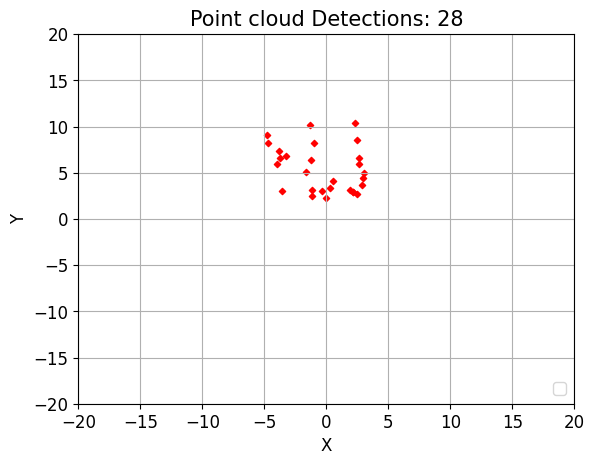

In [3]:
#get radar data #x,y,z,vel values for radar point cloud
#NOTE: Radar data is in FLU (x - forward, y - left, z - up)
radar_data = dataset.get_radar_point_cloud(idx=sample_idx)
print(f"loaded radar point cloud with shape: {radar_data.shape}")

plotter.plot_radar_detections(sample_idx=sample_idx,show=True)

loaded raw lidar point cloud with shape: (19968, 4)
loaded 2d lidar point cloud with shape: (1478, 2)


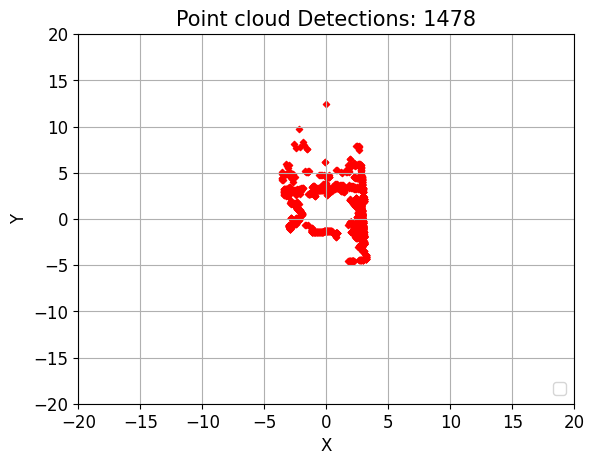

In [4]:
#get the raw lidar point cloud (x,y,z) also in FLU coordinates
lidar_data_raw = dataset.get_lidar_point_cloud_raw(idx=sample_idx)
print(f"loaded raw lidar point cloud with shape: {lidar_data_raw.shape}")


#get a 2D slice of the lidar data (x,y) directly out from the lidar in FLU coodinate frame
lidar_data_2d = dataset.get_lidar_point_cloud(idx=sample_idx)
print(f"loaded 2d lidar point cloud with shape: {lidar_data_2d.shape}")

plotter.plot_2d_lidar_detections_velodyne(sample_idx=sample_idx,show=True)

In [5]:
#get the camera data
camera_data = dataset.get_camera_frame(idx=sample_idx)
print(f"loaded camera image with shape: {camera_data.shape}")

plotter.plot_camera_data(
    sample_idx=sample_idx,
    show=True
)

AssertionError: No camera dataset loaded

AssertionError: No camera dataset loaded

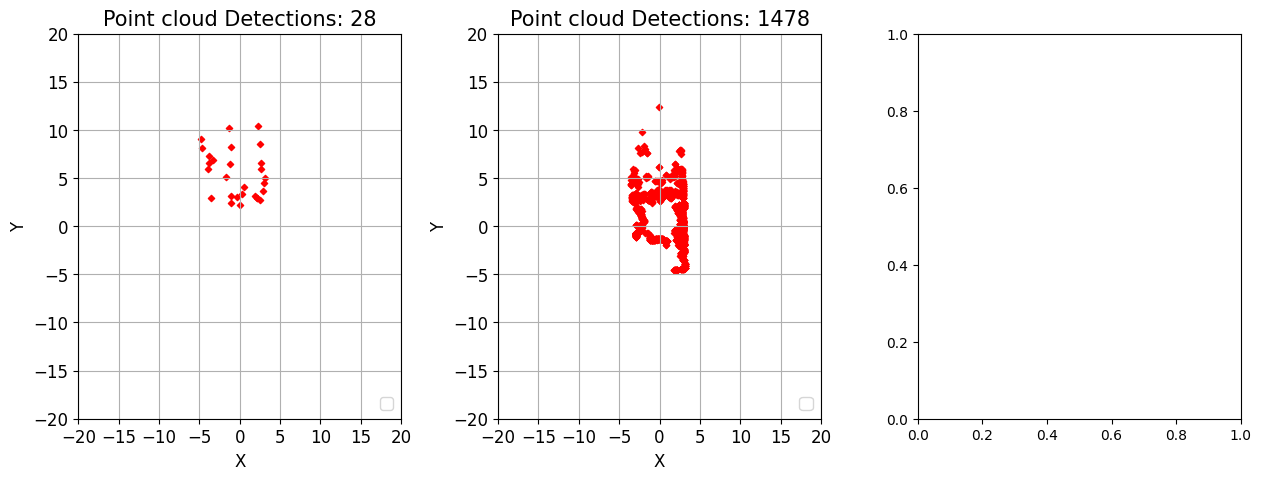

In [6]:
#plot a compilation
plotter.plot_compilation(idx=sample_idx,show=True)